In [ ]:
# Battery Data Analysis and Capacity Prediction

In [ ]:
## 1. Data Loading

In [1]:
import pandas as pd
import os

# check files inside data folder
data_files = os.listdir("data")
print("Number of files:", len(data_files))
print(data_files[:5])  # first 5 files

Number of files: 5630
['00005.csv', '00010.csv', '00012.csv', '00015.csv', '00017.csv']


In [2]:
# open one file
df = pd.read_csv("data/" + data_files[0])

# show first few rows
df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.186636,-0.001666,5.454957,0.0002,0.000,0.000
1,4.186626,-0.002432,5.485011,0.0002,4.203,9.297
2,4.001180,-0.995300,5.510369,1.0000,3.431,23.265
3,3.982544,-0.994923,5.581233,1.0000,3.411,36.437
4,3.968436,-0.995817,5.640744,1.0000,3.398,49.609


In [3]:
print(df.columns)

Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time'],
      dtype='object')


In [ ]:
## 2. Discharge Curve Analysis

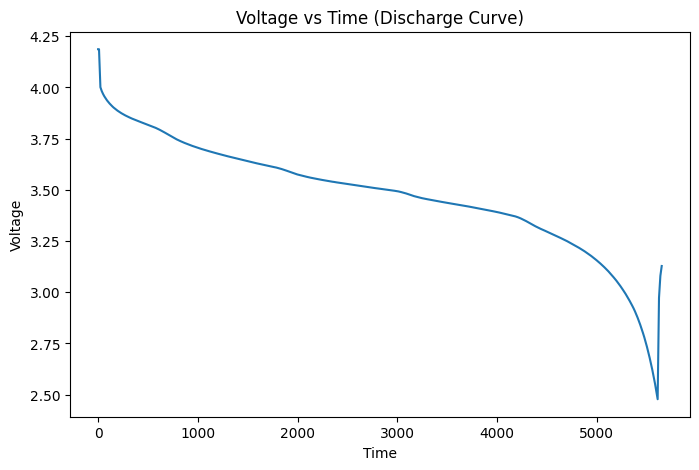

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df['Time'], df['Voltage_measured'])

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Voltage vs Time (Discharge Curve)")

plt.show()

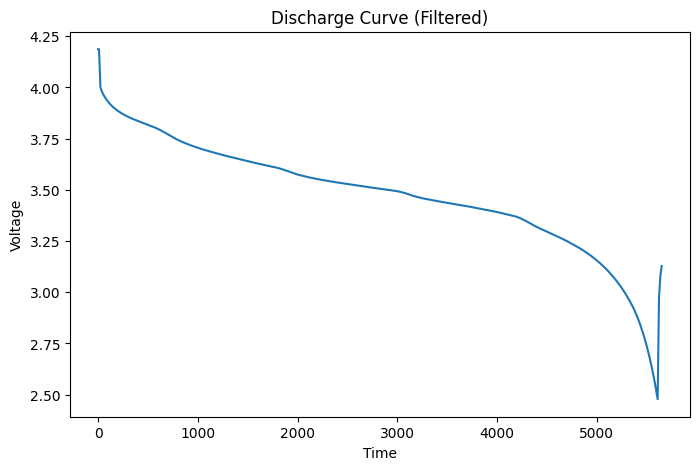

In [5]:
discharge_df = df[df['Current_measured'] < 0]

plt.figure(figsize=(8,5))
plt.plot(discharge_df['Time'], discharge_df['Voltage_measured'])

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Discharge Curve (Filtered)")

plt.show()

In [6]:
# time difference calculate
discharge_df['dt'] = discharge_df['Time'].diff().fillna(0)

# capacity calculation
discharge_df['Capacity'] = (discharge_df['Current_measured'] * discharge_df['dt']).cumsum()

# absolute value (since current negative)
discharge_df['Capacity'] = discharge_df['Capacity'].abs()

discharge_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,dt,Capacity
0,4.186636,-0.001666,5.454957,0.0002,0.000,0.000,0.000,0.000000
1,4.186626,-0.002432,5.485011,0.0002,4.203,9.297,9.297,0.022614
2,4.001180,-0.995300,5.510369,1.0000,3.431,23.265,13.968,13.924969
3,3.982544,-0.994923,5.581233,1.0000,3.411,36.437,13.172,27.030089
4,3.968436,-0.995817,5.640744,1.0000,3.398,49.609,13.172,40.146997


In [ ]:
## 3. Capacity Calculation

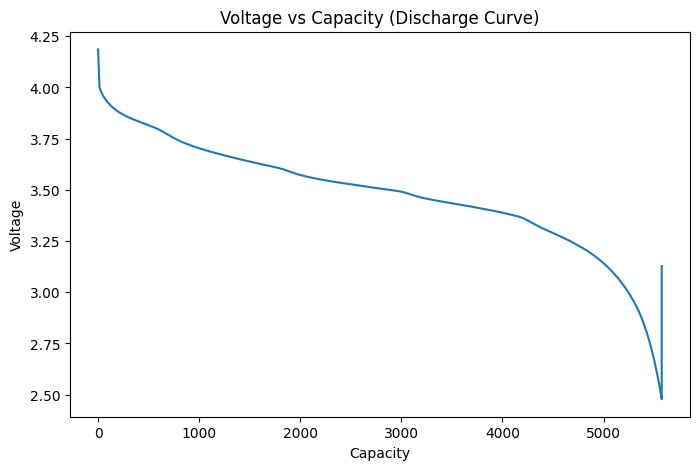

In [7]:
plt.figure(figsize=(8,5))

plt.plot(discharge_df['Capacity'], discharge_df['Voltage_measured'])

plt.xlabel("Capacity")
plt.ylabel("Voltage")
plt.title("Voltage vs Capacity (Discharge Curve)")

plt.show()

In [ ]:
## 4. dQ/dV Peak Analysis

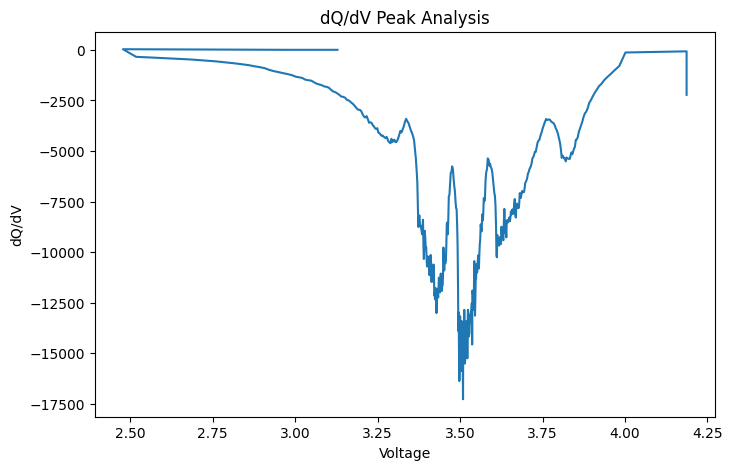

In [8]:
import numpy as np

# calculate gradients
dQ = np.gradient(discharge_df['Capacity'])
dV = np.gradient(discharge_df['Voltage_measured'])

# avoid division error
dQdV = dQ / dV

# plot
plt.figure(figsize=(8,5))
plt.plot(discharge_df['Voltage_measured'], dQdV)

plt.xlabel("Voltage")
plt.ylabel("dQ/dV")
plt.title("dQ/dV Peak Analysis")

plt.show()

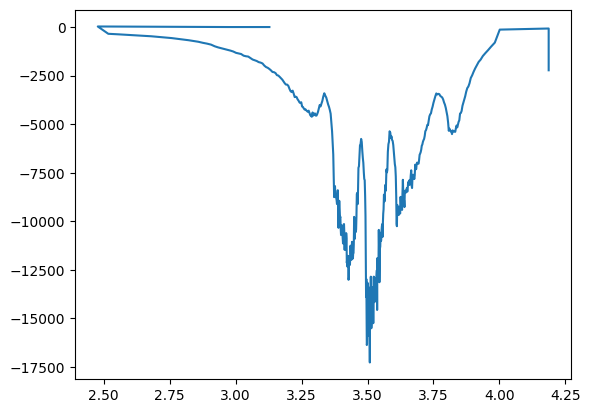

In [9]:
# remove inf / NaN
mask = np.isfinite(dQdV)

plt.plot(discharge_df['Voltage_measured'][mask], dQdV[mask])

In [ ]:
## 5. Machine Learning Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# features
X = discharge_df[['Voltage_measured', 'Current_measured', 'Temperature_measured']]

# target
y = discharge_df['Capacity']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
score = model.score(X_test, y_test)
print("Model Accuracy:", score)

Model Accuracy: 0.8959784868853675


In [13]:
plt.savefig("voltage_vs_time.png")
plt.savefig("voltage_vs_capacity.png")
plt.savefig("dq_dv.png")

<Figure size 640x480 with 0 Axes>